## Plume Seasonality with NextGEMS - FESOM

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pylab as plt
import matplotlib.cm as cm
import cmocean.cm as cmo
from scipy.interpolate import CloughTocher2DInterpolator, LinearNDInterpolator, NearestNDInterpolator
import gribscan
import intake
import uxarray as ux
from scipy.interpolate import griddata
from tqdm import tqdm

#### NextGEMS functions

In [2]:
def attach_coords(ds):
    model_lon = ds.lon.values
    model_lat = ds.lat.values
    return ds.assign_coords(
        lat = (("value",), model_lat, {"units": "degree_north"}),
        lon = (("value",), model_lon, {"units": "degree_east"}),
    )


def attach_depth_coords(ds):
    nz1  = [2.5, 7.5, 12.5, 17.5, 22.5, 27.5, 32.5, 37.5, 42.5, 47.5, 52.5, 57.5,
    62.5, 67.5, 72.5, 77.5, 82.5, 87.5, 92.5, 97.5, 105, 115, 125, 135, 145,
    155, 165, 175, 185, 195, 210, 230, 250, 270, 290, 320, 360, 400, 440,
    480, 520, 560, 600, 640, 710, 810, 950, 1110, 1255, 1415, 1600, 1810,
    2035, 2275, 2525, 2775, 3025, 3275, 3525, 3775, 4025, 4275, 4525, 4775,
    5025, 5275, 5525, 5825, 6175, 6175]
    nz = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85,
    90, 95, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200, 220, 240,
    260, 280, 300, 340, 380, 420, 460, 500, 540, 580, 620, 660, 760, 860,
    1040, 1180, 1330, 1500, 1700, 1920, 2150, 2400, 2650, 2900, 3150, 3400,
    3650, 3900, 4150, 4400, 4650, 4900, 5150, 5400, 5650, 6000, 6350]
    return ds.assign_coords(
        nz1 = (("level",), nz1, {"units": "m"}),
        nz = (("level",), nz, {"units": "m"}),
    )


nz1  = [2.5, 7.5, 12.5, 17.5, 22.5, 27.5, 32.5, 37.5, 42.5, 47.5, 52.5, 57.5,
    62.5, 67.5, 72.5, 77.5, 82.5, 87.5, 92.5, 97.5, 105, 115, 125, 135, 145,
    155, 165, 175, 185, 195, 210, 230, 250, 270, 290, 320, 360, 400, 440,
    480, 520, 560, 600, 640, 710, 810, 950, 1110, 1255, 1415, 1600, 1810,
    2035, 2275, 2525, 2775, 3025, 3275, 3525, 3775, 4025, 4275, 4525, 4775,
    5025, 5275, 5525, 5825, 6175, 6175]

nz = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85,
    90, 95, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200, 220, 240,
    260, 280, 300, 340, 380, 420, 460, 500, 540, 580, 620, 660, 760, 860,
    1040, 1180, 1330, 1500, 1700, 1920, 2150, 2400, 2650, 2900, 3150, 3400,
    3650, 3900, 4150, 4400, 4650, 4900, 5150, 5400, 5650, 6000, 6350]

### Processing Functions

In [3]:
def season_mean(data):

    ss = data['time'].dt.season
    ss_means = data.groupby(ss).mean('time')
    return ss_means

def monthly_mean(data):
    
    season = data.groupby('time.month').mean(dim='time')
    return season

## Loading Data

### Choosing a model from NextGEMs

In [4]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="zarr.core.metadata.v2")
cat = intake.open_catalog("https://data.nextgems-h2020.eu/catalog.yaml")
list(cat)

['ICON', 'IFS', 'FESOM', 'ERA5', 'JRA3Q', 'MERRA2']

In [5]:
list(cat.FESOM)

['IFS_4.4-FESOM_5-cycle3',
 'IFS_28-FESOM_25-cycle3',
 'IFS_9-FESOM_5-cycle3',
 'FESOM_13_tropo_age_interpolated']

In [6]:
list(cat.FESOM['IFS_4.4-FESOM_5-cycle3'])

['2D_1h_0.25deg',
 '2D_1h_1deg',
 '2D_1h_native',
 '2D_daily_0.25deg',
 '2D_daily_1deg',
 '2D_daily_native',
 '2D_monthly_0.25deg',
 '2D_monthly_1deg',
 '2D_monthly_native',
 '3D_3h_native',
 '3D_3h_native_zarr',
 '3D_daily_native',
 '3D_daily_native_zarr',
 '3D_monthly_0.25deg',
 '3D_monthly_1deg',
 'elem_grid',
 'node_grid',
 'data_inventory']

### Mesh Creation

In [7]:
cat = intake.open_catalog("https://data.nextgems-h2020.eu/catalog.yaml")
## Mesh
# source = cat.FESOM["IFS_4.4-FESOM_5-cycle3"]["node_grid"]
# Load the native mesh (nodes)  
nodes = cat.FESOM["IFS_4.4-FESOM_5-cycle3"]["node_grid"].reader.read(engine="netcdf4", chunks={})
elems = cat.FESOM["IFS_4.4-FESOM_5-cycle3"]["elem_grid"].reader.read(engine="netcdf4", chunks={})

elems

<xarray.Dataset> Size: 2GB
Dimensions:          (grid_size: 14741520, grid_corners: 3, grid_rank: 1,
                      ncells: 7402886, nlinks_max: 8)
Dimensions without coordinates: grid_size, grid_corners, grid_rank, ncells,
                                nlinks_max
Data variables:
    grid_center_lon  (grid_size) float64 118MB dask.array<chunksize=(14741520,), meta=np.ndarray>
    grid_corner_lon  (grid_size, grid_corners) float64 354MB dask.array<chunksize=(14741520, 3), meta=np.ndarray>
    grid_center_lat  (grid_size) float64 118MB dask.array<chunksize=(14741520,), meta=np.ndarray>
    grid_corner_lat  (grid_size, grid_corners) float64 354MB dask.array<chunksize=(14741520, 3), meta=np.ndarray>
    grid_dims        (grid_rank) float64 8B dask.array<chunksize=(1,), meta=np.ndarray>
    grid_imask       (grid_size) float64 118MB dask.array<chunksize=(14741520,), meta=np.ndarray>
    cell_area        (grid_size) float64 118MB dask.array<chunksize=(14741520,), meta=np.ndarray>
    node_node_links  (ncells, nlinks_max) float64 474MB dask.array<chunksize=(7402886, 8), meta=np.ndarray>
    triag_nodes      (grid_size, grid_corners) float64 354MB dask.array<chunksize=(14741520, 3), meta=np.ndarray>
    coast            (grid_size) float64 118MB dask.array<chunksize=(14741520,), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.4
    history:      2022-03-19 08:26:26 GMT; Grid description file generated wi...

In [8]:
#to -180 - 180
nodes["grid_center_lon"] = nodes["grid_center_lon"].where(nodes["grid_center_lon"] <= 180, other=nodes["grid_center_lon"] - 360)
nodes.grid_center_lon.compute()

<xarray.DataArray 'grid_center_lon' (grid_size: 7402886)> Size: 59MB
array([-177.24840837, -177.30976646, -177.31453329, ...,  178.49163036,
        178.28238769,  178.28138628], shape=(7402886,))
Dimensions without coordinates: grid_size
Attributes:
    units:          degrees
    standard_name:  longitude
    bounds:         grid_corner_lon

In [9]:
## Create a mesh

# 1)Extraer nodos
lon_nodes = nodes['grid_center_lon'].data
lat_nodes = nodes['grid_center_lat'].data

# 2)Extraer elementos
face_nodes = elems['triag_nodes'].astype(int)  # (ntriags, 3)

face_nodes_T = face_nodes.transpose('grid_corners', 'grid_size')
face_nodes_T = face_nodes_T.rename({'grid_corners': 'n3', 'grid_size': 'elem'})

# 3)Crear Dataset simulado tipo FESOM
ds_mesh = xr.Dataset(
    coords={
        'nod2': ('nod2', np.arange(len(lon_nodes)) + 1),
        'elem': ('elem', np.arange(len(face_nodes)) + 1),
        'n3': ('n3', [0, 1, 2]), 
        'nz': ('nz', nz),
        'nz1': ('nz1', nz1)
    },
    data_vars={
        'lat': ('nod2', lat_nodes.compute()),
        'lon': ('nod2', lon_nodes.compute()),
        'face_nodes': (('n3', 'elem'), face_nodes_T.data.compute()),  # necesitas transponer para (3, elem)
        # 'nz1_depth': ('nz1', nodes['depth_lev'].data),   # opcional
    }
)

# ds_mesh.to_netcdf('IFS_4.4-FESOM_5-cycle3_mesh.nc')

In [10]:
elem_corner_lons = ds_mesh.lon.sel(nod2=ds_mesh.face_nodes)
elem_corner_lats = ds_mesh.lat.sel(nod2=ds_mesh.face_nodes)

elem_corner_lons
elem_corner_lats

<xarray.DataArray 'lat' (n3: 3, elem: 14741520)> Size: 354MB
array([[-78.09547211, -78.09547211, -78.05118113, ..., -77.66438078,
        -77.79325323, -77.84855478],
       [-78.07051367, -78.12237992, -77.99910232, ..., -77.68937816,
        -77.81741389, -77.81741389],
       [-78.05118113, -78.07051367, -78.02426051, ..., -77.63815229,
        -77.84855478, -77.86335343]], shape=(3, 14741520))
Coordinates:
    nod2     (n3, elem) int64 354MB 1 1 2 2 ... 7402879 7402881 7402884 7402886
  * elem     (elem) int64 118MB 1 2 3 4 ... 14741517 14741518 14741519 14741520
  * n3       (n3) int64 24B 0 1 2

In [11]:
display(elem_corner_lats.isel(elem=slice(None, 3)).compute().data)
display(elem_corner_lons.isel(elem=slice(None, 3)).compute().data)

array([[-78.09547211, -78.09547211, -78.05118113],
       [-78.07051367, -78.12237992, -77.99910232],
       [-78.05118113, -78.07051367, -78.02426051]])

array([[-177.24840837, -177.24840837, -177.30976646],
       [-177.0763871 , -177.07404167, -177.31453329],
       [-177.30976646, -177.0763871 , -177.48220808]])

In [12]:
elem_center_lons = elem_corner_lons.mean("n3")
elem_center_lats = elem_corner_lats.mean("n3")

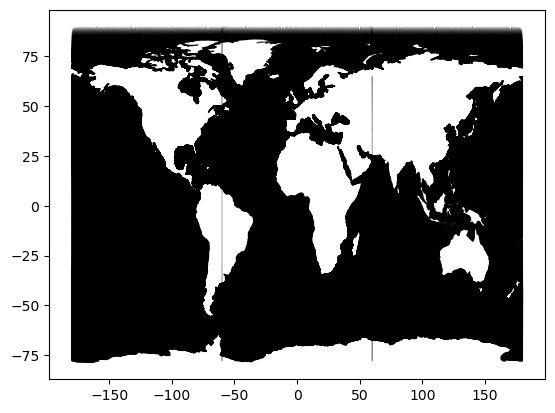

In [13]:
plt.scatter(elem_center_lons, elem_center_lats, s=1, alpha=0.05, edgecolor="none", facecolor="k")

In [14]:
ds_mesh = ds_mesh.assign_coords(
    elem_center_lons=elem_center_lons.compute(),
    elem_center_lats=elem_center_lats.compute(),
)

ds_mesh

<xarray.Dataset> Size: 885MB
Dimensions:           (nod2: 7402886, n3: 3, elem: 14741520, nz: 70, nz1: 70)
Coordinates:
  * nod2              (nod2) int64 59MB 1 2 3 4 ... 7402884 7402885 7402886
  * elem              (elem) int64 118MB 1 2 3 4 ... 14741518 14741519 14741520
  * n3                (n3) int64 24B 0 1 2
  * nz                (nz) int64 560B 0 5 10 15 20 ... 5150 5400 5650 6000 6350
  * nz1               (nz1) float64 560B 2.5 7.5 12.5 ... 6.175e+03 6.175e+03
    elem_center_lons  (elem) float64 118MB -177.2 -177.1 -177.4 ... 178.4 178.4
    elem_center_lats  (elem) float64 118MB -78.07 -78.1 -78.02 ... -77.82 -77.84
Data variables:
    lat               (nod2) float64 59MB -78.1 -78.05 -78.0 ... -77.82 -77.86
    lon               (nod2) float64 59MB -177.2 -177.3 -177.3 ... 178.3 178.3
    face_nodes        (n3, elem) int64 354MB 1 1 2 2 ... 7402881 7402884 7402886

In [15]:
import xoak
ds_mesh.xoak.set_index(["elem_center_lats", "elem_center_lons"], "sklearn_geo_balltree")

In [16]:
display(ds_mesh.lon.data.min(), ds_mesh.lon.data.max())

display(ds_mesh.lat.data.min(), ds_mesh.lat.data.max())

np.float64(-179.999914324336)

np.float64(179.999850601809)

np.float64(-78.618019336954)

np.float64(89.9944190470223)

In [17]:
grid_lon = xr.DataArray(np.linspace(-180, 180, 360*4), dims=("grid_lon", ))
grid_lat = xr.DataArray(np.linspace(-90, 90, 180*4), dims=("grid_lat", ))

In [18]:
target_lon, target_lat = xr.broadcast(grid_lon, grid_lat)

In [19]:
grid_elems = ds_mesh.xoak.sel(
    elem_center_lats=target_lat,
    elem_center_lons=target_lon,
).elem

grid_elems = grid_elems.assign_coords(
    target_lat=target_lat,
    target_lon=target_lon,
)

grid_elems = grid_elems.assign_coords(
    grid_lat=grid_lat,
    grid_lon=grid_lon,
)

grid_elems

<xarray.DataArray 'elem' (grid_lon: 1440, grid_lat: 720)> Size: 8MB
array([[  59748,   59748,   59748, ..., 8954048, 5291527, 5780576],
       [  59748,   59748,   59748, ..., 8954048, 5291527, 5780576],
       [  59748,   59748,   59748, ..., 8954048, 5291527, 5780576],
       ...,
       [  59748,   59748,   59748, ..., 8954048, 5291527, 5780576],
       [  59748,   59748,   59748, ..., 8954048, 5291527, 5780576],
       [  59748,   59748,   59748, ..., 8954048, 5291527, 5780576]],
      shape=(1440, 720))
Coordinates:
    elem              (grid_lon, grid_lat) int64 8MB 59748 59748 ... 5780576
    elem_center_lons  (grid_lon, grid_lat) float64 8MB -163.7 -163.7 ... 77.6
    elem_center_lats  (grid_lon, grid_lat) float64 8MB -78.6 -78.6 ... 89.97
    target_lat        (grid_lon, grid_lat) float64 8MB -90.0 -89.75 ... 90.0
    target_lon        (grid_lon, grid_lat) float64 8MB -180.0 -180.0 ... 180.0
  * grid_lat          (grid_lat) float64 6kB -90.0 -89.75 -89.5 ... 89.75 90.0
  * grid_lon          (grid_lon) float64 12kB -180.0 -179.7 ... 179.7 180.0

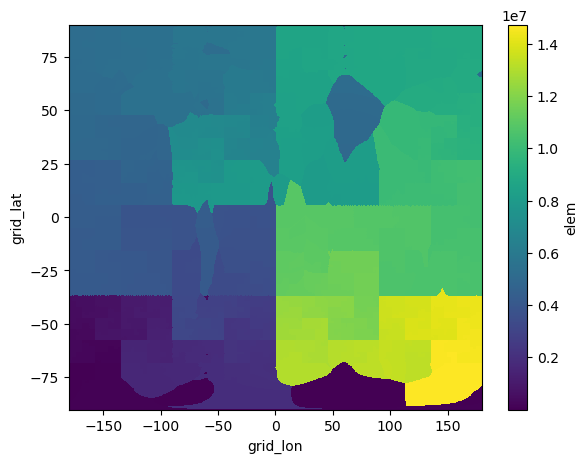

In [20]:
grid_elems.plot.imshow(x="grid_lon", y="grid_lat", size=5)

## FESOM Data

In [30]:
ds = cat.FESOM["IFS_4.4-FESOM_5-cycle3"]["3D_daily_native"].reader.read(
    engine="netcdf4",
    chunks={
    "time": 30,     # 1 month per chunk
    "lev": 10,      # vertical levels (e.g., 10 levels per chunk)
    "value": 1_000_000,  # number of spatial points per chunk
    },
)
ds = ds[['u', 'v', 'salt']]
ds

<xarray.Dataset> Size: 18TB
Dimensions:  (time: 1808, nz1: 69, elem: 14741520, nod2: 7402886)
Coordinates:
    lon      (nod2) float64 59MB dask.array<chunksize=(7402886,), meta=np.ndarray>
    lat      (nod2) float64 59MB dask.array<chunksize=(7402886,), meta=np.ndarray>
  * time     (time) datetime64[ns] 14kB 2020-01-20T23:56:00 ... 2024-12-31T23...
  * nz1      (nz1) float64 552B 2.5 7.5 12.5 ... 5.525e+03 5.825e+03 6.175e+03
Dimensions without coordinates: elem, nod2
Data variables:
    u        (time, nz1, elem) float32 7TB dask.array<chunksize=(12, 1, 460673), meta=np.ndarray>
    v        (time, nz1, elem) float32 7TB dask.array<chunksize=(12, 1, 460673), meta=np.ndarray>
    salt     (time, nz1, nod2) float32 4TB dask.array<chunksize=(12, 2, 321865), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.4
    history:      2022-03-19 08:26:17 GMT; Grid description file generated wi...

### UV seasonality

In [31]:
U_grid = ds.isel(nz1=0).u.isel(elem=grid_elems - 1)
V_grid = ds.isel(nz1=0).v.isel(elem=grid_elems - 1)
# U_grid.plot(x='grid_lon',y='grid_lat',robust=True)
V_grid.sel(grid_lon=slice(-75,-35),grid_lat=slice(-10,30))

UV = (U_grid**2 + V_grid**2)**0.5

UV = UV.chunk({'time': 90, 'grid_lon': 480, 'grid_lat': 360})
UV

<xarray.DataArray (time: 1808, grid_lon: 1440, grid_lat: 720)> Size: 7GB
dask.array<rechunk-merge, shape=(1808, 1440, 720), dtype=float32, chunksize=(90, 480, 360), chunktype=numpy.ndarray>
Coordinates:
  * time              (time) datetime64[ns] 14kB 2020-01-20T23:56:00 ... 2024...
    nz1               float64 8B 2.5
    elem              (grid_lon, grid_lat) int64 8MB dask.array<chunksize=(480, 360), meta=np.ndarray>
    elem_center_lons  (grid_lon, grid_lat) float64 8MB dask.array<chunksize=(480, 360), meta=np.ndarray>
    elem_center_lats  (grid_lon, grid_lat) float64 8MB dask.array<chunksize=(480, 360), meta=np.ndarray>
    target_lat        (grid_lon, grid_lat) float64 8MB dask.array<chunksize=(480, 360), meta=np.ndarray>
    target_lon        (grid_lon, grid_lat) float64 8MB dask.array<chunksize=(480, 360), meta=np.ndarray>
  * grid_lat          (grid_lat) float64 6kB -90.0 -89.75 -89.5 ... 89.75 90.0
  * grid_lon          (grid_lon) float64 12kB -180.0 -179.7 ... 179.7 180.0

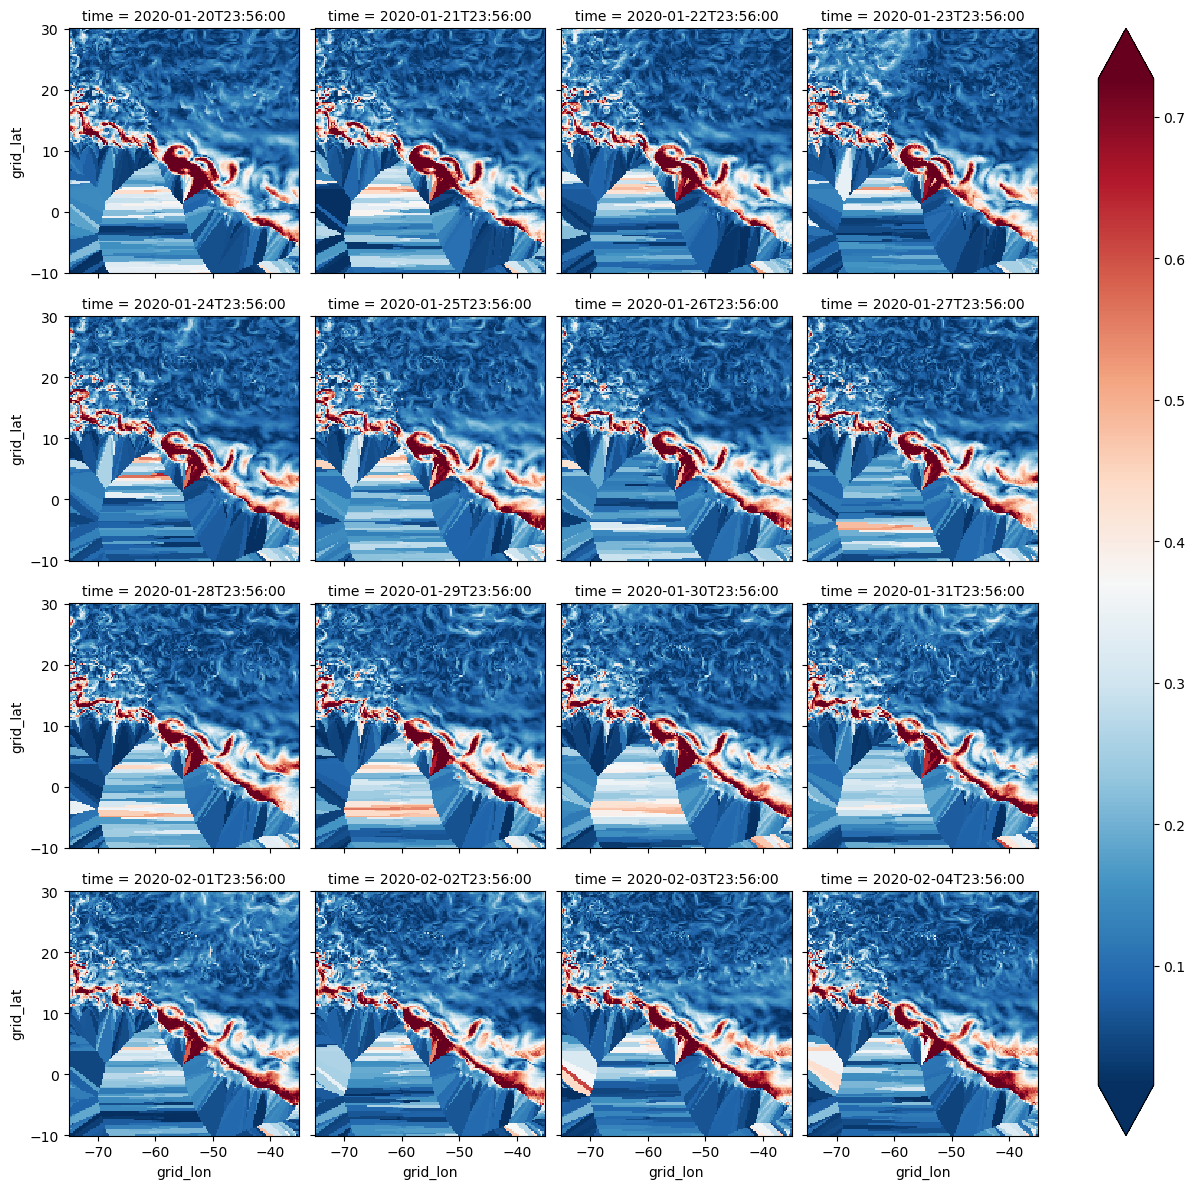

In [24]:
UV.sel(grid_lon=slice(-75,-35),grid_lat=slice(-10,30)).isel(time=slice(None, 16)).plot(
    x="grid_lon", y="grid_lat", col="time", col_wrap=4, robust=True, cmap= 'RdBu_r')

In [34]:
UV = UV.chunk({"time": 365}) 
uv_season = season_mean(UV)

uv_season

<xarray.DataArray (season: 4, grid_lon: 1440, grid_lat: 720)> Size: 17MB
dask.array<stack, shape=(4, 1440, 720), dtype=float32, chunksize=(1, 480, 360), chunktype=numpy.ndarray>
Coordinates:
    nz1               float64 8B 2.5
    elem              (grid_lon, grid_lat) int64 8MB dask.array<chunksize=(480, 360), meta=np.ndarray>
    elem_center_lons  (grid_lon, grid_lat) float64 8MB dask.array<chunksize=(480, 360), meta=np.ndarray>
    elem_center_lats  (grid_lon, grid_lat) float64 8MB dask.array<chunksize=(480, 360), meta=np.ndarray>
    target_lat        (grid_lon, grid_lat) float64 8MB dask.array<chunksize=(480, 360), meta=np.ndarray>
    target_lon        (grid_lon, grid_lat) float64 8MB dask.array<chunksize=(480, 360), meta=np.ndarray>
  * grid_lat          (grid_lat) float64 6kB -90.0 -89.75 -89.5 ... 89.75 90.0
  * grid_lon          (grid_lon) float64 12kB -180.0 -179.7 ... 179.7 180.0
  * season            (season) object 32B 'DJF' 'JJA' 'MAM' 'SON'

In [ ]:
uv_season.sel(grid_lon=slice(-75,-35),grid_lat=slice(-10,30)).plot(
    x="grid_lon", y="grid_lat",col="season", col_wrap=4, robust=True,
           figsize=(12, 3),cmap='RdBu_r',add_colorbar=True)

In [30]:
# uv_seasonp = uv_seasonp.reset_coords(
#     names=['elem', 'elem_center_lons', 'elem_center_lats', 'target_lon', 'target_lat','nz1'],
#     drop=True
# )
uv_seasonp

<xarray.DataArray (season: 4, grid_lon: 160, grid_lat: 160)> Size: 410kB
dask.array<getitem, shape=(4, 160, 160), dtype=float32, chunksize=(1, 100, 120), chunktype=numpy.ndarray>
Coordinates:
  * grid_lat  (grid_lat) float64 1kB -9.889 -9.638 -9.388 ... 29.42 29.67 29.92
  * grid_lon  (grid_lon) float64 1kB -74.93 -74.68 -74.43 ... -35.4 -35.15
  * season    (season) object 32B 'DJF' 'JJA' 'MAM' 'SON'

### Salinity

In [38]:
  ## modify the mesh for nodes and 
ds_mesh = ds_mesh.assign_coords(
        lat=("nod2", ds_mesh.lat.data.flatten()),
        lon=("nod2", ds_mesh.lon.data.flatten()),
    )
    # Ensure the xoak index 
ds_mesh.xoak.set_index(["lat", "lon"], "sklearn_geo_balltree")

#-------------get the nod2grids
grid_nodes = ds_mesh.xoak.sel(
        lat = target_lat,
        lon = target_lon,
    ).nod2
grid_nodes

<xarray.DataArray 'nod2' (grid_lon: 1440, grid_lat: 720)> Size: 8MB
array([[  29590,   29590,   29590, ..., 4497231, 2648152, 2897521],
       [  29590,   29590,   29590, ..., 4497231, 2648152, 2897521],
       [  29590,   29590,   29590, ..., 4497231, 2648152, 2897521],
       ...,
       [  29590,   29590,   29590, ..., 4497231, 2648152, 2897521],
       [  29590,   29590,   29590, ..., 4497231, 2648152, 2897521],
       [  29590,   29590,   29590, ..., 4497231, 2648152, 2897521]],
      shape=(1440, 720))
Coordinates:
    lat      (grid_lon, grid_lat) float64 8MB -78.62 -78.62 ... 89.77 89.99
    lon      (grid_lon, grid_lat) float64 8MB -163.6 -163.6 ... -178.7 -48.1
    nod2     (grid_lon, grid_lat) int64 8MB 29590 29590 ... 2648152 2897521
Dimensions without coordinates: grid_lon, grid_lat

In [61]:
ds_mesh

<xarray.Dataset> Size: 885MB
Dimensions:           (nod2: 7402886, n3: 3, elem: 14741520, nz: 70, nz1: 70)
Coordinates:
    lat               (nod2) float64 59MB -78.1 -78.05 -78.0 ... -77.82 -77.86
    lon               (nod2) float64 59MB -177.2 -177.3 -177.3 ... 178.3 178.3
  * nod2              (nod2) int64 59MB 1 2 3 4 ... 7402884 7402885 7402886
  * elem              (elem) int64 118MB 1 2 3 4 ... 14741518 14741519 14741520
  * n3                (n3) int64 24B 0 1 2
  * nz                (nz) int64 560B 0 5 10 15 20 ... 5150 5400 5650 6000 6350
  * nz1               (nz1) float64 560B 2.5 7.5 12.5 ... 6.175e+03 6.175e+03
    elem_center_lons  (elem) float64 118MB -177.2 -177.1 -177.4 ... 178.4 178.4
    elem_center_lats  (elem) float64 118MB -78.07 -78.1 -78.02 ... -77.82 -77.84
Data variables:
    face_nodes        (n3, elem) int64 354MB 1 1 2 2 ... 7402881 7402884 7402886

In [41]:
sal= ds.isel(nz1=0).salt.isel(nod2=grid_nodes - 1)
# sal_region = sal_region.compute()
sal 

<xarray.DataArray 'salt' (time: 1808, grid_lon: 1440, grid_lat: 720)> Size: 7GB
dask.array<transpose, shape=(1808, 1440, 720), dtype=float32, chunksize=(30, 447, 720), chunktype=numpy.ndarray>
Coordinates:
    lon      (grid_lon, grid_lat) float64 8MB dask.array<chunksize=(1440, 720), meta=np.ndarray>
    lat      (grid_lon, grid_lat) float64 8MB dask.array<chunksize=(1440, 720), meta=np.ndarray>
  * time     (time) datetime64[ns] 14kB 2020-01-20T23:56:00 ... 2024-12-31T23...
    nz1      float64 8B 2.5
    nod2     (grid_lon, grid_lat) int64 8MB 29590 29590 ... 2648152 2897521
Dimensions without coordinates: grid_lon, grid_lat
Attributes:
    description:  salinity
    long_name:    salinity
    units:        psu

In [68]:
sal['lon'] = UV.grid_lon
sal['lat'] = UV.grid_lat
sal

<xarray.DataArray 'salt' (time: 1808, grid_lon: 1440, grid_lat: 720)> Size: 7GB
dask.array<transpose, shape=(1808, 1440, 720), dtype=float32, chunksize=(30, 447, 720), chunktype=numpy.ndarray>
Coordinates:
    lon       (grid_lon) float64 12kB -180.0 -179.7 -179.5 ... 179.5 179.7 180.0
    lat       (grid_lat) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * time      (time) datetime64[ns] 14kB 2020-01-20T23:56:00 ... 2024-12-31T2...
    nz1       float64 8B 2.5
    nod2      (grid_lon, grid_lat) int64 8MB 29590 29590 ... 2648152 2897521
  * grid_lon  (grid_lon) float64 12kB -180.0 -179.7 -179.5 ... 179.5 179.7 180.0
  * grid_lat  (grid_lat) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
Attributes:
    description:  salinity
    long_name:    salinity
    units:        psu

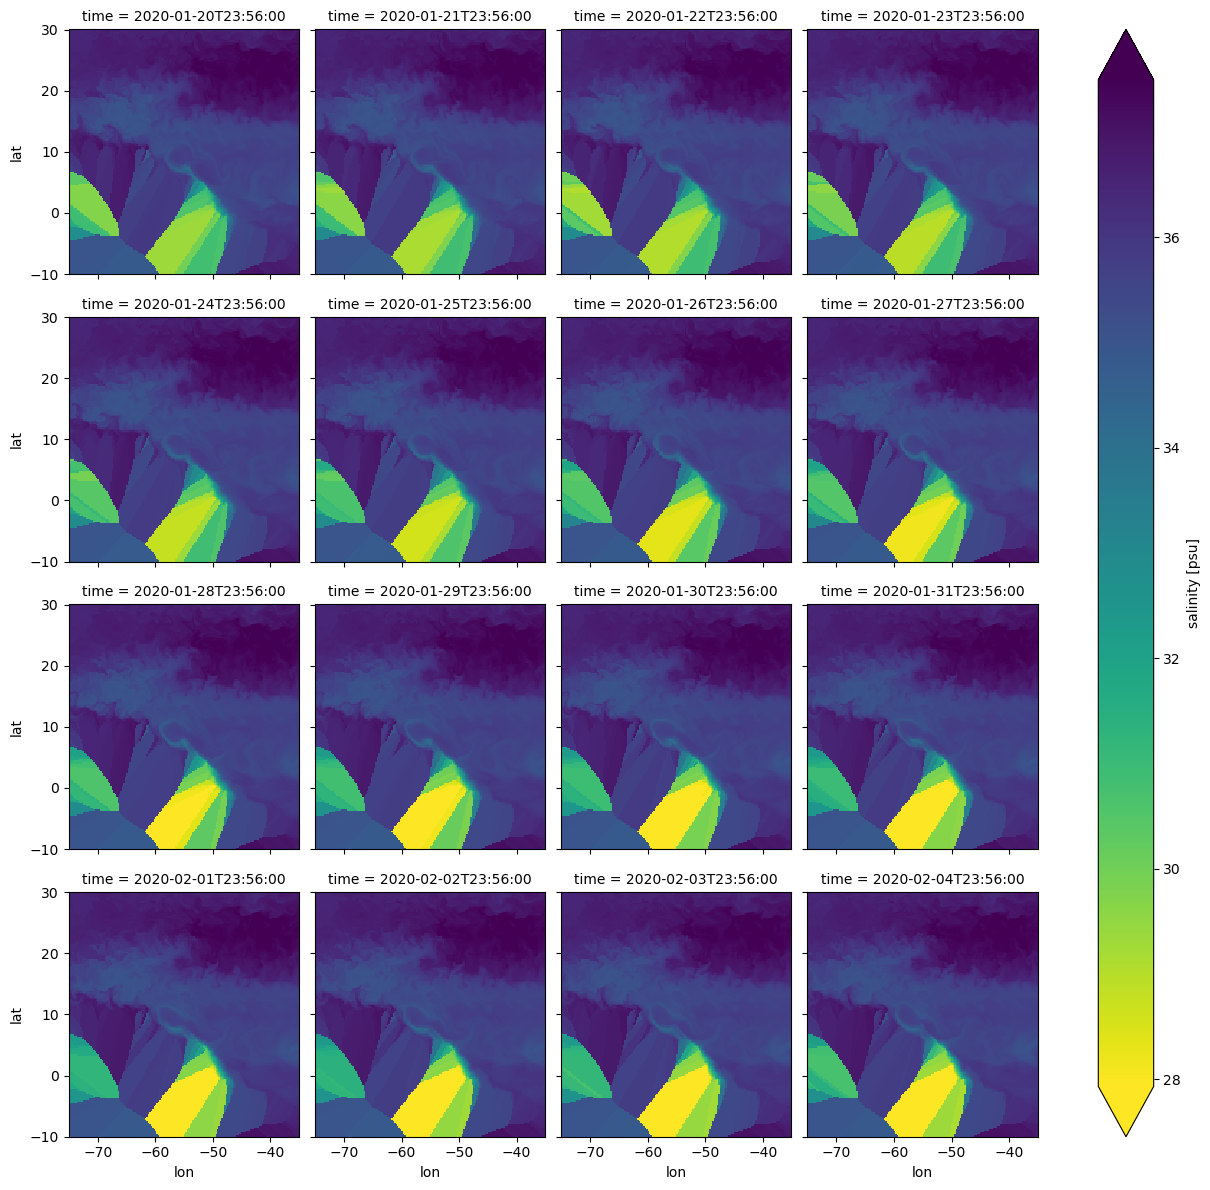

In [71]:
sal.sel(grid_lon=slice(-75,-35),grid_lat=slice(-10,30)).isel(time=slice(None, 16)).plot(
    x="lon", y="lat", col="time", col_wrap=4, robust=True, cmap= 'viridis_r')

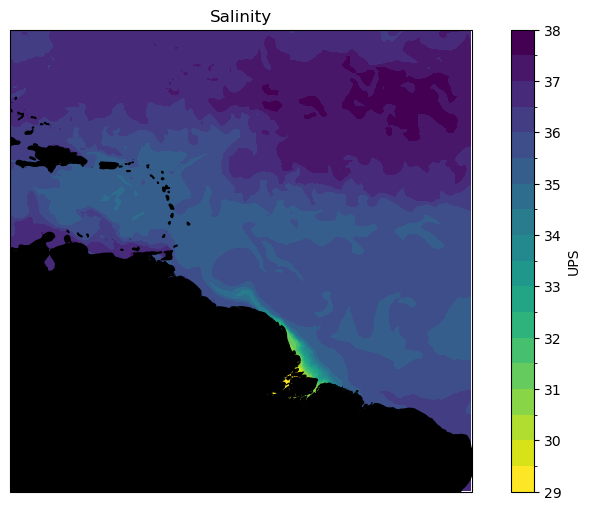

In [90]:
# sal.sel(grid_lon=slice(-75,-35),grid_lat=slice(-10,30)).isel(time=0).plot(
#     x="grid_lon", y="grid_lat",cmap='viridis_r')

import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import cartopy

# Selección de la región y el primer timestep
sal_map = sal.sel(grid_lon=slice(-75, -35), grid_lat=slice(-10, 30)).isel(time=0)

# Crear figura y ejes con proyección
fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Establecer fondo blanco
# ax.set_facecolor("white")

# Agregar datos
sal_map.plot.contourf(
    ax=ax,
    transform=ccrs.PlateCarree(),
    x='grid_lon',
    y='grid_lat',
    cmap='viridis_r',
    cbar_kwargs={'label': 'UPS'},
    robust=True,levels=20
)

land = ax.add_feature(
    cartopy.feature.NaturalEarthFeature('physical','land','10m', facecolor='black'))

# Añadir detalles del mapa
ax.coastlines()
ax.set_title('Salinity')
ax.set_extent([-75, -35, -10, 30], crs=ccrs.PlateCarree())

plt.show()


In [70]:
# Load node coordinates (nods dataset)
node_lon = mesh_nodes.grid_center_lon.values  # shape: (n_nodes,)
node_lat = mesh_nodes.grid_center_lat.values  # shape: (n_nodes,)
face_nodes = mesh_elems.triag_nodes.values.astype(np.int32)  # Ensure int32

# Define UXarray-compatible dictionaries
node_coords = {"lon": node_lon, "lat": node_lat}
face_connectivity = {"face_nodes": face_nodes}


# Create UXarray grid
grid = ux.Grid.from_face_vertices(
    face_vertices=np.column_stack([node_lon, node_lat])[face_nodes - 1]  # 0-based indexing
)

grid

<uxarray.Grid>
Original Grid Type: Face Vertices
Grid Dimensions:
  * n_node: 7402886
  * n_face: 14741520
  * n_max_face_nodes: 3
Grid Coordinates (Spherical):
  * node_lon: (7402886,)
  * node_lat: (7402886,)
Grid Coordinates (Cartesian):
Grid Connectivity Variables:
  * face_node_connectivity: (14741520, 3)
Grid Descriptor Variables:

In [75]:
ds_subset = ds_subset.compute()
ds_subset

<xarray.Dataset> Size: 650MB
Dimensions:    (nod2: 7402886, nelem: 14741520, three: 3, elem: 14741520)
Coordinates:
    lon        (nod2) float64 59MB -177.2 -177.3 -177.3 ... 178.5 178.3 178.3
    lat        (nod2) float64 59MB -78.1 -78.05 -78.0 ... -77.85 -77.82 -77.86
    faces      (nelem, three) uint32 177MB 0 1168 1 ... 7402883 7402884 7402885
    nz         float64 8B 0.0
    time       datetime64[ns] 8B 2020-01-20T23:56:00
    nz1        float64 8B 2.5
Dimensions without coordinates: nod2, nelem, three, elem
Data variables:
    node_area  (nod2) float64 59MB 7.714e+06 1.701e+07 ... 2.715e+07 8.304e+06
    Av         (elem) float32 59MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    u          (elem) float32 59MB -0.1466 -0.1002 -0.183 ... -0.4379 -0.3815
    temp       (nod2) float32 30MB 1.488 1.444 1.25 1.446 ... 1.308 1.363 1.271
    salt       (nod2) float32 30MB 33.37 33.33 33.28 33.34 ... 33.36 33.35 33.37
    Kv         (nod2) float32 30MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    w          (nod2) float32 30MB 1.518e-20 6.596e-20 ... -7.265e-20 -4.768e-21
    v          (elem) float32 59MB 0.123 0.144 0.1947 ... 0.02283 -0.007586
Attributes:
    Conventions:  CF-1.4
    history:      2022-03-19 08:26:17 GMT; Grid description file generated wi...

In [77]:
uxds = ux.UxDataset(ds_subset, grid=grid)
uxds

AttributeError: 'NoneType' object has no attribute '_ds'

<xarray.UxDataset> Size: 650MB
Dimensions:    (nod2: 7402886, nelem: 14741520, three: 3, elem: 14741520)
Coordinates:
    lon        (nod2) float64 59MB -177.2 -177.3 -177.3 ... 178.5 178.3 178.3
    lat        (nod2) float64 59MB -78.1 -78.05 -78.0 ... -77.85 -77.82 -77.86
    faces      (nelem, three) uint32 177MB 0 1168 1 ... 7402883 7402884 7402885
    nz         float64 8B 0.0
    time       datetime64[ns] 8B 2020-01-20T23:56:00
    nz1        float64 8B 2.5
Dimensions without coordinates: nod2, nelem, three, elem
Data variables:
    node_area  (nod2) float64 59MB 7.714e+06 1.701e+07 ... 2.715e+07 8.304e+06
    Av         (elem) float32 59MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    u          (elem) float32 59MB -0.1466 -0.1002 -0.183 ... -0.4379 -0.3815
    temp       (nod2) float32 30MB 1.488 1.444 1.25 1.446 ... 1.308 1.363 1.271
    salt       (nod2) float32 30MB 33.37 33.33 33.28 33.34 ... 33.36 33.35 33.37
    Kv         (nod2) float32 30MB 0.0 0.0 0.0 0.0 0.0 ... 0.0

In [15]:
sal_season = season_mean(ds_subset.sel(value=pnts.values).avg_so)
sal_season

<xarray.DataArray 'avg_so' (season: 4, value: 40000)> Size: 1MB
dask.array<stack, shape=(4, 40000), dtype=float64, chunksize=(1, 40000), chunktype=numpy.ndarray>
Coordinates:
    level    int64 8B 1
    lon      (value) float64 320kB dask.array<chunksize=(40000,), meta=np.ndarray>
    lat      (value) float64 320kB dask.array<chunksize=(40000,), meta=np.ndarray>
    nz1      float64 8B 2.5
    nz       int64 8B 0
  * season   (season) object 32B 'DJF' 'JJA' 'MAM' 'SON'
Dimensions without coordinates: value
Attributes: (12/14)
    paramId:                    263500
    dataType:                   fc
    numberOfPoints:             3145728
    typeOfLevel:                oceanModelLayer
    stepUnits:                  1
    stepType:                   avg
    ...                         ...
    units:                      g kg**-1
    name:                       Time-mean sea water practical salinity
    cfVarName:                  avg_so
    missingValue:               9999
    NV:                         0
    gridDefinitionDescription:  150

In [ ]:
# Get the coordinates
lons_orig = sal_season.lon.values  # o data.lon si el nombre es distinto
lats_orig = sal_season.lat.values

# Combine the points with vstack
points = np.column_stack([lons_orig, lats_orig])

sal_s = get_data(sal_season, points, lats, lons, method='linear')

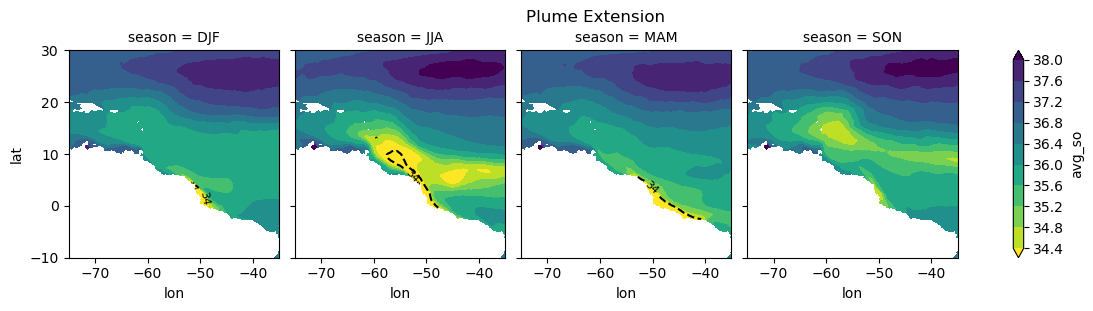

In [49]:
g = sal_s.plot.contourf(col="season", col_wrap=4, robust=True, 
                                     figsize=(12, 3),cmap='viridis_r',add_colorbar=True, levels=10)

# Add 30 psu contour lines to each subplot
for ax, season in zip(g.axs.flat, sal_s.season.values):  # Use g.axs instead of g.axes
    # Select 2D data for this specific season
    season_data = sal_s.sel(season=season)
    
    # Squeeze to ensure 2D (remove any singleton dimensions)
    contour_data = season_data.squeeze()
    
    # Plot contour
    cs = ax.contour(
        contour_data.lon, 
        contour_data.lat, 
        contour_data,
        levels=[34],
        colors='black',
        linewidths=1.5,
        linestyles='--'
    )
    # Optional: Add contour labels
    ax.clabel(cs, inline=True, fontsize=8, fmt='%.f')

# Adjust layout and add title
plt.suptitle("Plume Extension", y=1.02)
# plt.tight_layout()
# plt.savefig('Figures/Sal_season'+'.png', format='png', dpi=300, transparent=False, bbox_inches='tight')
plt.show()

## Monthly mean

In [16]:
sal_month = monthly_mean(ds_subset.sel(value=pnts.values).avg_so)
sal_month

<xarray.DataArray 'avg_so' (month: 12, value: 40000)> Size: 4MB
dask.array<stack, shape=(12, 40000), dtype=float64, chunksize=(1, 40000), chunktype=numpy.ndarray>
Coordinates:
    level    int64 8B 1
    lon      (value) float64 320kB dask.array<chunksize=(40000,), meta=np.ndarray>
    lat      (value) float64 320kB dask.array<chunksize=(40000,), meta=np.ndarray>
    nz1      float64 8B 2.5
    nz       int64 8B 0
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Dimensions without coordinates: value
Attributes: (12/14)
    paramId:                    263500
    dataType:                   fc
    numberOfPoints:             3145728
    typeOfLevel:                oceanModelLayer
    stepUnits:                  1
    stepType:                   avg
    ...                         ...
    units:                      g kg**-1
    name:                       Time-mean sea water practical salinity
    cfVarName:                  avg_so
    missingValue:               9999
    NV:                         0
    gridDefinitionDescription:  150

In [31]:
sal_m = get_data(sal_month, points, lats, lons, method='linear')
sal_m

Interpolating month data: 100%|██████████| 12/12 [02:21<00:00, 11.76s/it]


<xarray.DataArray 'avg_so' (month: 12, lat: 200, lon: 200)> Size: 4MB
array([[[        nan,         nan,         nan, ..., 36.38056754,
         36.39871529,         nan],
        [        nan,         nan,         nan, ..., 36.37228861,
         36.38080214, 36.40098607],
        [        nan,         nan,         nan, ..., 36.38206287,
         36.36314398, 36.38721468],
        ...,
        [36.94813684, 36.95298766, 36.95507902, ..., 37.39069195,
         37.39384896, 37.39958003],
        [36.94675016, 36.94859177, 36.95147412, ..., 37.37418596,
         37.36911075, 37.35178979],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan]],

       [[        nan,         nan,         nan, ..., 36.36738664,
         36.36538459,         nan],
        [        nan,         nan,         nan, ..., 36.38947837,
         36.36225503, 36.35734833],
        [        nan,         nan,         nan, ..., 36.4283547 ,
         36.36969796, 36.35007579],
...
        [36.88360556, 36.87435016, 36.86420389, ..., 37.70325148,
         37.69388847, 37.69787091],
        [36.87636778, 36.87495624, 36.86378983, ..., 37.66667156,
         37.66446485, 37.65991446],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan]],

       [[        nan,         nan,         nan, ..., 36.37468394,
         36.38191856,         nan],
        [        nan,         nan,         nan, ..., 36.39544834,
         36.38040314, 36.38606783],
        [        nan,         nan,         nan, ..., 36.44000295,
         36.38071805, 36.38018255],
        ...,
        [36.94572604, 36.9441485 , 36.937687  , ..., 37.60171965,
         37.59350701, 37.59345459],
        [36.94174852, 36.93844238, 36.93364139, ..., 37.55010308,
         37.5521375 , 37.5409552 ],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan]]], shape=(12, 200, 200))
Coordinates:
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * lat      (lat) float64 2kB -10.0 -9.799 -9.598 -9.397 ... 29.6 29.8 30.0
  * lon      (lon) float64 2kB -75.0 -74.8 -74.6 -74.4 ... -35.4 -35.2 -35.0

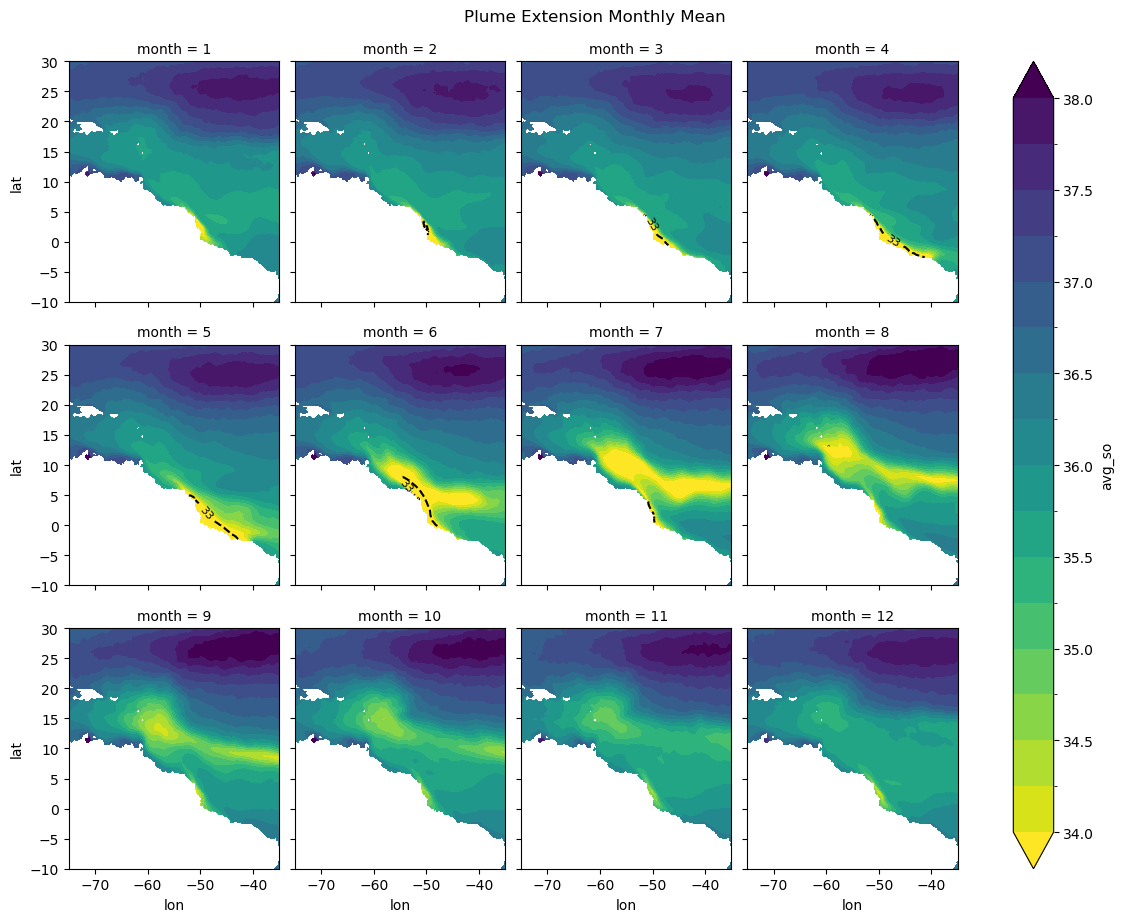

In [47]:
g = sal_m.plot.contourf(col="month", col_wrap=4, robust=True, 
                                     figsize=(12, 9),cmap='viridis_r',add_colorbar=True, levels=20)

# Add 30 psu contour lines to each subplot
for ax, month in zip(g.axs.flat, sal_m.month.values):  # Use g.axs instead of g.axes
    # Select 2D data for this specific season
    season_data = sal_m.sel(month=month)
    
    # Squeeze to ensure 2D (remove any singleton dimensions)
    contour_data = season_data.squeeze()
    
    # Plot contour
    cs = ax.contour(
        contour_data.lon, 
        contour_data.lat, 
        contour_data,
        levels=[33],
        colors='black',
        linewidths=1.5,
        linestyles='--'
    )
    # Optional: Add contour labels
    ax.clabel(cs, inline=True, fontsize=8, fmt='%.f')

# Adjust layout and add title
plt.suptitle("Plume Extension Monthly Mean", y=1.02)
# plt.tight_layout()
# plt.savefig('Figures/Sal_season'+'.png', format='png', dpi=300, transparent=False, bbox_inches='tight')
plt.show()

### UV monthly mean

In [50]:
uv_month = monthly_mean(uv)
uv_month

<xarray.DataArray (month: 12, value: 40000)> Size: 4MB
dask.array<stack, shape=(12, 40000), dtype=float64, chunksize=(1, 40000), chunktype=numpy.ndarray>
Coordinates:
    level    int64 8B 1
    lon      (value) float64 320kB dask.array<chunksize=(40000,), meta=np.ndarray>
    lat      (value) float64 320kB dask.array<chunksize=(40000,), meta=np.ndarray>
    nz1      float64 8B 2.5
    nz       int64 8B 0
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Dimensions without coordinates: value

In [51]:
uv_m = get_data(uv_month, points, lats, lons, method='linear')
uv_m

Interpolating month data: 100%|██████████| 12/12 [04:40<00:00, 23.41s/it]


<xarray.DataArray 'interpolated' (month: 12, lat: 200, lon: 200)> Size: 4MB
array([[[       nan,        nan,        nan, ..., 0.22088622,
         0.14293473,        nan],
        [       nan,        nan,        nan, ..., 0.36767721,
         0.19848763, 0.12013211],
        [       nan,        nan,        nan, ..., 0.4274392 ,
         0.26632063, 0.1459884 ],
        ...,
        [0.20217635, 0.19176521, 0.17503596, ..., 0.0770017 ,
         0.07548405, 0.07651461],
        [0.21139918, 0.19765767, 0.18711659, ..., 0.07645189,
         0.07640047, 0.07537679],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]],

       [[       nan,        nan,        nan, ..., 0.17322231,
         0.15152925,        nan],
        [       nan,        nan,        nan, ..., 0.25072596,
         0.17439466, 0.15384516],
        [       nan,        nan,        nan, ..., 0.28424019,
         0.21207669, 0.16034387],
...
        [0.18978945, 0.18525541, 0.17291195, ..., 0.08347871,
         0.08471097, 0.08473411],
        [0.19832233, 0.19465449, 0.17900745, ..., 0.08160078,
         0.08085978, 0.08077039],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]],

       [[       nan,        nan,        nan, ..., 0.34053182,
         0.21667467,        nan],
        [       nan,        nan,        nan, ..., 0.50212905,
         0.3020027 , 0.17266878],
        [       nan,        nan,        nan, ..., 0.55004398,
         0.39389315, 0.22214472],
        ...,
        [0.17290989, 0.17189284, 0.16838765, ..., 0.08188502,
         0.07816476, 0.07462361],
        [0.18386938, 0.18611578, 0.18335673, ..., 0.07862038,
         0.07579627, 0.07441735],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]]], shape=(12, 200, 200))
Coordinates:
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * lat      (lat) float64 2kB -10.0 -9.799 -9.598 -9.397 ... 29.6 29.8 30.0
  * lon      (lon) float64 2kB -75.0 -74.8 -74.6 -74.4 ... -35.4 -35.2 -35.0

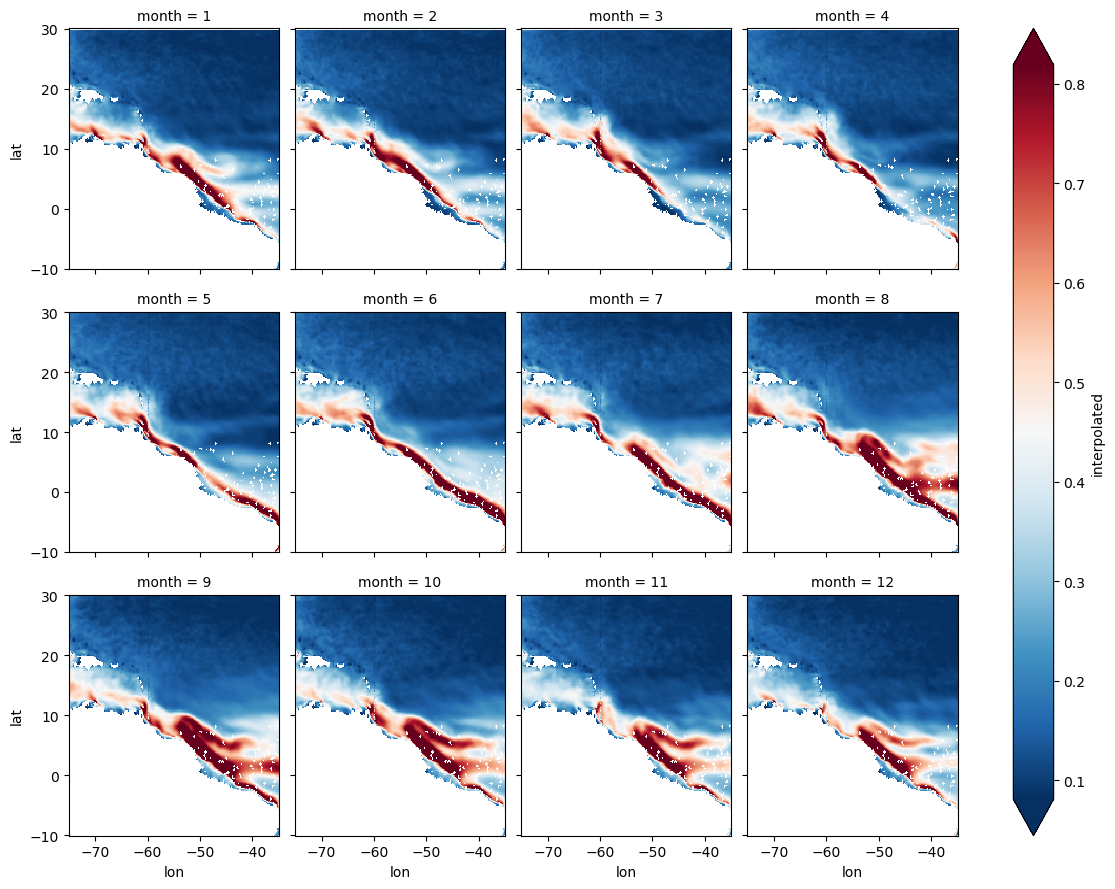

In [53]:
uv_m.plot(col="month", col_wrap=4, robust=True,
           figsize=(12, 9),cmap='RdBu_r',add_colorbar=True)

### Alternative with uxarray

In [47]:
# ds_subset["lon"] = ds_subset["lon"].where(ds_subset["lon"] <= 180, other=ds_subset["lon"] - 360)

In [48]:
lon = ds_subset.lon.compute()
lat = ds_subset.lat.compute()

In [49]:
lon.data.min(), lon.data.max()

(np.float64(-179.999914324336), np.float64(179.999850601809))

In [30]:
ds_subset.v.compute()

<xarray.DataArray 'v' (elem: 14741520)> Size: 59MB
array([ 0.12297777,  0.1440431 ,  0.19469227, ...,  0.00125434,
        0.02282857, -0.00758599], shape=(14741520,), dtype=float32)
Coordinates:
    nz       float64 8B 0.0
    time     datetime64[ns] 8B 2020-01-20T23:56:00
    nz1      float64 8B 2.5
Dimensions without coordinates: elem
Attributes:
    description:  meridional velocity
    long_name:    meridional velocity
    units:        m/s

In [54]:
## define the amazon plume region 
lon_min, lon_max = -75, -35.0  
lat_min, lat_max = -10.0, 30.0  

In [61]:
mesh_nodes["grid_center_lon"] = mesh_nodes["grid_center_lon"].where(mesh_nodes["grid_center_lon"] <= 180, other=mesh_nodes["grid_center_lon"] - 360)
# mesh_nodes.grid_center_lon.compute()

mesh_elems["grid_center_lon"] = mesh_elems["grid_center_lon"].where( mesh_elems["grid_center_lon"] <= 180, other= mesh_elems["grid_center_lon"] - 360)
mesh_elems.grid_center_lon.compute()

<xarray.DataArray 'grid_center_lon' (grid_size: 14741520)> Size: 118MB
array([-177.21154762, -177.13295048, -177.36884207, ...,  178.40679566,
        178.41989067,  178.35177118], shape=(14741520,))
Dimensions without coordinates: grid_size
Attributes:
    units:          degrees
    standard_name:  longitude
    bounds:         grid_corner_lon

In [59]:
# Mask for nodes inside the bounding box
node_mask = (
    (mesh_nodes.grid_center_lon >= lon_min) & 
    (mesh_nodes.grid_center_lon <= lon_max) & 
    (mesh_nodes.grid_center_lat >= lat_min) & 
    (mesh_nodes.grid_center_lat <= lat_max)
)

node_mask = node_mask.compute() 
# Get indices of nodes in the area
node_indices =mesh_nodes.grid_size.where(node_mask, drop=True)  # shape: (n_nodes_in_region,)

node_indices

<xarray.DataArray 'grid_size' (grid_size: 252833)> Size: 2MB
array([1816053., 1816054., 1816055., ..., 4019310., 4019311., 4019312.],
      shape=(252833,))
Dimensions without coordinates: grid_size

In [62]:
## Elements mask
elem_mask = (
    (mesh_elems.grid_center_lon >= lon_min) & 
    (mesh_elems.grid_center_lon <= lon_max) & 
    (mesh_elems.grid_center_lat >= lat_min) & 
    (mesh_elems.grid_center_lat <= lat_max)
)

elem_mask = elem_mask.compute()
# Get indices of elements in the area
elem_indices = mesh_elems.grid_size.where(elem_mask, drop=True)  # shape: (n_elems_in_region,)

elem_indices

<xarray.DataArray 'grid_size' (grid_size: 504256)> Size: 4MB
array([3630357., 3630358., 3630359., ..., 8013934., 8013935., 8013937.],
      shape=(504256,))
Dimensions without coordinates: grid_size